# Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 12

# Load Excel

In [2]:
excel_path = r"ToothFairy3_Label_Analysis.xlsx"

df = pd.read_excel(excel_path)

print(df.shape)
df.head()

(77, 9)


,Label ID,Label Name,Cases Present,Presence %,Total Voxels,Mean Voxels,Median Voxels,Min Voxels,Max Voxels
0,1,Lower Jawbone,532,100.00,828087394,1556555,1528107,521383,2942737
1,3,Left Inferior Alveolar Canal,532,100.00,7933456,14912,14483,6198,32604
2,4,Right Inferior Alveolar Canal,532,100.00,8048610,15128,14678,5610,30354
3,7,Pharynx,532,100.00,258369432,485656,436694,71533,1503552
4,105,Lingual Canal,519,97.56,154736,298,276,6,835


# Dataset Summary Table

In [3]:
summary = pd.DataFrame({
    "Property":[
        "Dataset",
        "Scans",
        "Classes",
        "Foreground Classes"
    ],
    "Value":[
        "ToothFairy3",
        532,
        77,
        76
    ]
})

summary

,Property,Value
0,Dataset,ToothFairy3
1,Scans,532
2,Classes,77
3,Foreground Classes,76


# Top 20 Most Frequent Structures

In [4]:
top20 = df.sort_values(
    "Presence %",
    ascending=False
).head(20)

top20[
    ["Label ID",
     "Label Name",
     "Presence %"]
]

,Label ID,Label Name,Presence %
0,1,Lower Jawbone,100.00
1,3,Left Inferior Alveolar Canal,100.00
2,4,Right Inferior Alveolar Canal,100.00
3,7,Pharynx,100.00
4,105,Lingual Canal,97.56
5,103,Left Mandibular Incisive Canal,94.55
6,104,Right Mandibular Incisive Canal,92.86
7,43,Lower Right Canine,92.67
8,143,Lower Right Canine Pulp,91.92
9,33,Lower Left Canine,91.35


# Save Publication Table

In [5]:
top20.to_excel(
    "Table1_Top20_Structures.xlsx",
    index=False
)

print("Saved")

Saved


# Label Frequency Figure

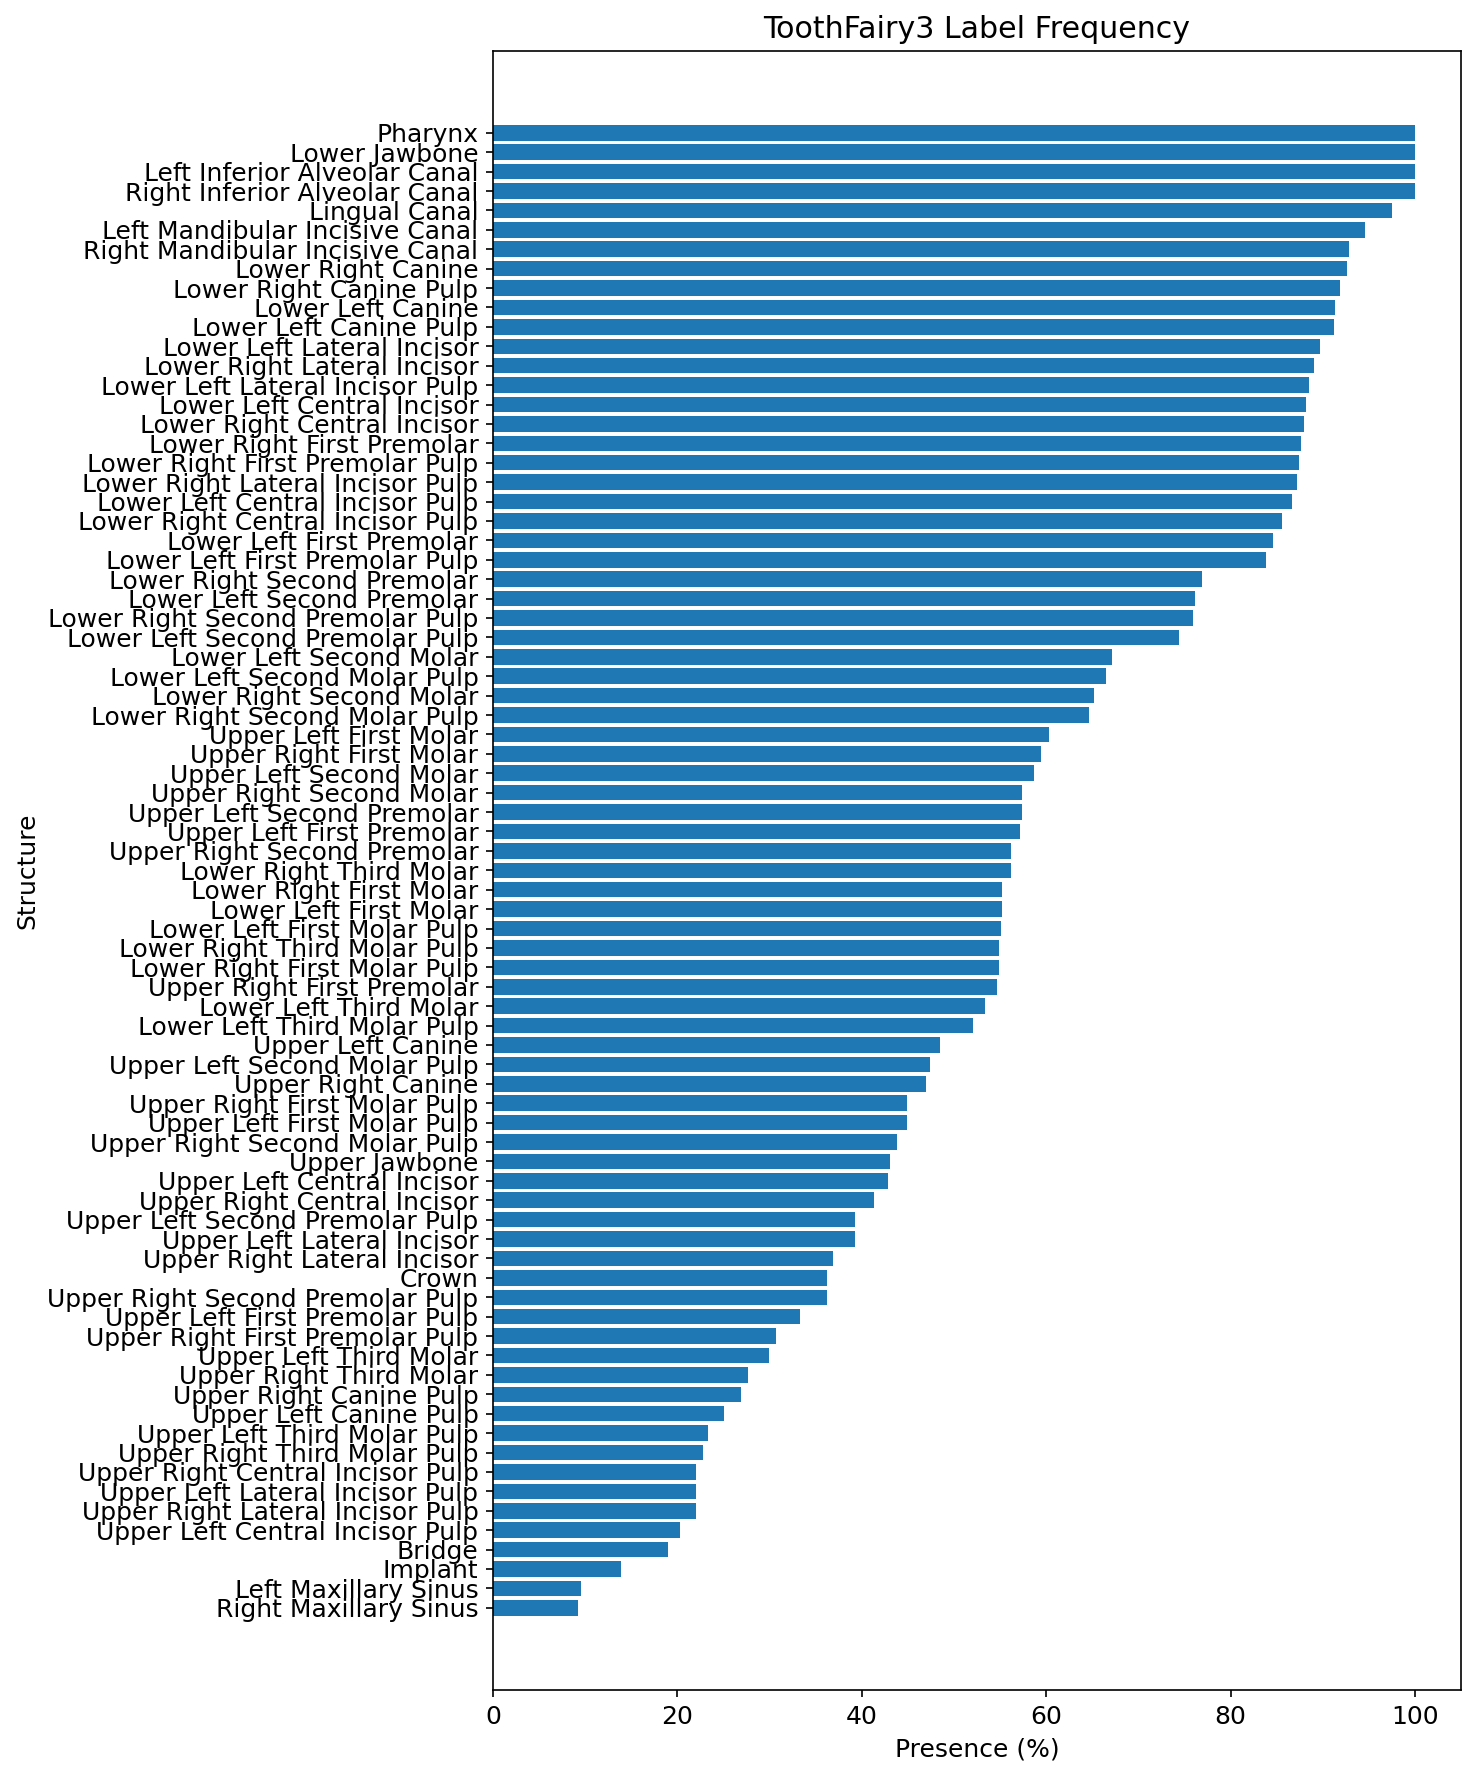

In [6]:
plt.figure(figsize=(10,12))

plot_df = df.sort_values(
    "Presence %",
    ascending=True
)

plt.barh(
    plot_df["Label Name"],
    plot_df["Presence %"]
)

plt.xlabel("Presence (%)")
plt.ylabel("Structure")
plt.title("ToothFairy3 Label Frequency")

plt.tight_layout()

plt.savefig(
    "Figure1_Label_Frequency.png",
    bbox_inches="tight"
)

plt.show()

# Class Imbalance Analysis

In [7]:
imbalance = df.sort_values(
    "Mean Voxels",
    ascending=False
)

imbalance.head()

,Label ID,Label Name,Cases Present,Presence %,Total Voxels,Mean Voxels,Median Voxels,Min Voxels,Max Voxels
0,1,Lower Jawbone,532,100.00,828087394,1556555,1528107,521383,2942737
3,7,Pharynx,532,100.00,258369432,485656,436694,71533,1503552
53,2,Upper Jawbone,229,43.05,37784803,164999,52518,113,1713008
59,9,Crown,193,36.28,11357143,58845,46626,10798,326864
76,6,Right Maxillary Sinus,49,9.21,2567212,52392,49952,431,154257


# Class Imbalance Figure (Log Scale)

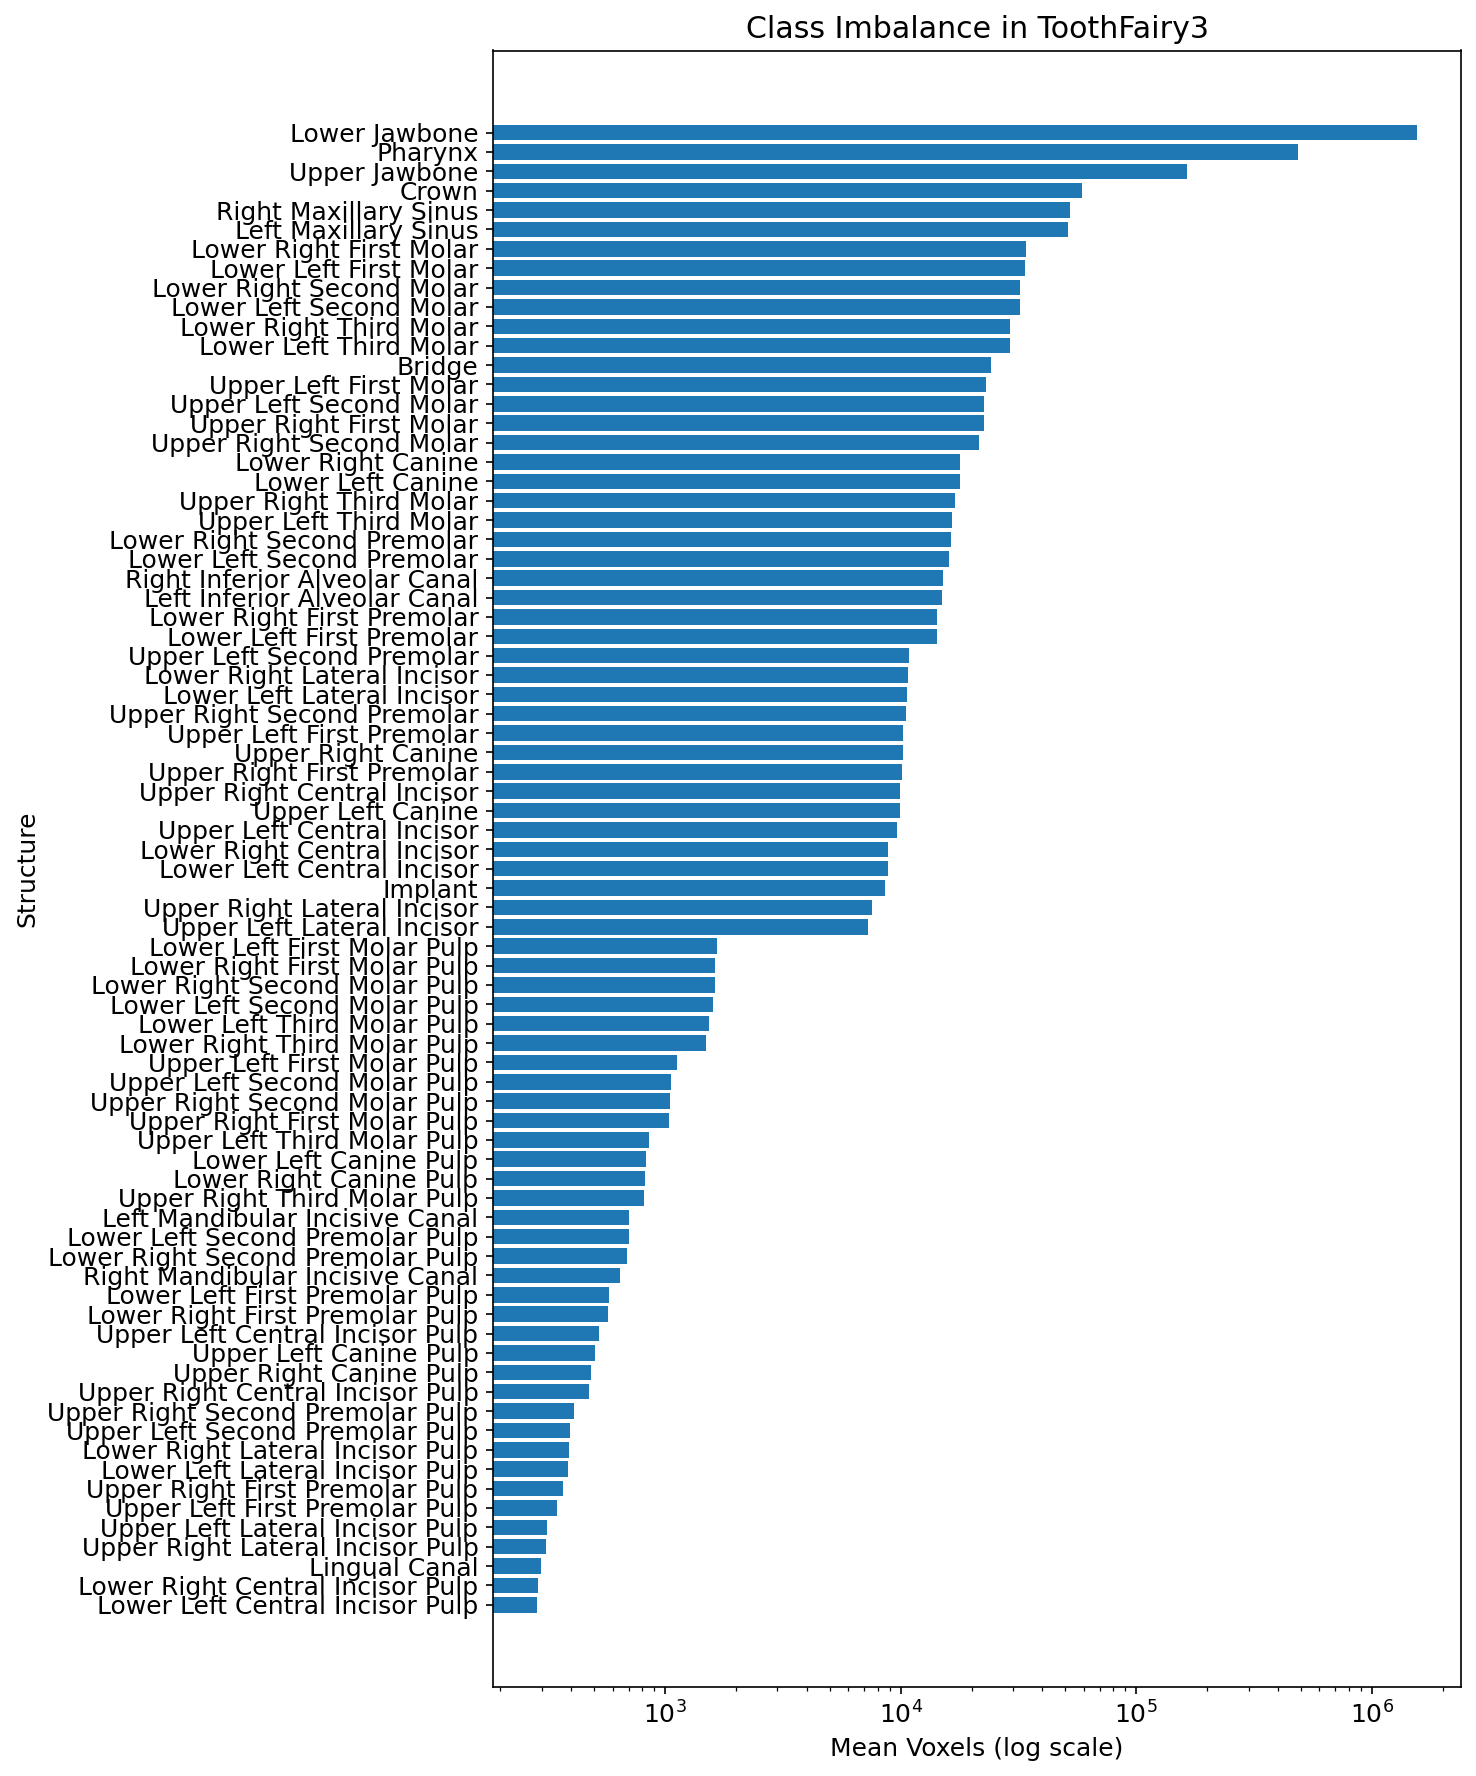

In [8]:
plt.figure(figsize=(10,12))

plot_df = df.sort_values(
    "Mean Voxels",
    ascending=True
)

plt.barh(
    plot_df["Label Name"],
    plot_df["Mean Voxels"]
)

plt.xscale("log")

plt.xlabel("Mean Voxels (log scale)")
plt.ylabel("Structure")

plt.title(
    "Class Imbalance in ToothFairy3"
)

plt.tight_layout()

plt.savefig(
    "Figure2_Class_Imbalance.png",
    bbox_inches="tight"
)

plt.show()

# Category Assignment

In [9]:
def get_category(name):

    name = str(name)

    if "Pulp" in name:
        return "Pulp"

    if any(
        x in name
        for x in [
            "Incisor",
            "Canine",
            "Premolar",
            "Molar"
        ]
    ):
        return "Tooth"

    if "Jawbone" in name:
        return "Bone"

    if "Canal" in name:
        return "Canal"

    if "Sinus" in name:
        return "Sinus"

    if "Pharynx" in name:
        return "Airway"

    if any(
        x in name
        for x in [
            "Bridge",
            "Crown",
            "Implant"
        ]
    ):
        return "Restoration"

    return "Other"


df["Category"] = df[
    "Label Name"
].apply(get_category)

df.head()

,Label ID,Label Name,Cases Present,Presence %,Total Voxels,Mean Voxels,Median Voxels,Min Voxels,Max Voxels,Category
0,1,Lower Jawbone,532,100.00,828087394,1556555,1528107,521383,2942737,Bone
1,3,Left Inferior Alveolar Canal,532,100.00,7933456,14912,14483,6198,32604,Canal
2,4,Right Inferior Alveolar Canal,532,100.00,8048610,15128,14678,5610,30354,Canal
3,7,Pharynx,532,100.00,258369432,485656,436694,71533,1503552,Airway
4,105,Lingual Canal,519,97.56,154736,298,276,6,835,Canal


# Category Distribution Table

In [10]:
category_table = (
    df.groupby("Category")
      .size()
      .reset_index(name="Count")
)

category_table

,Category,Count
0,Airway,1
1,Bone,2
2,Canal,5
3,Pulp,32
4,Restoration,3
5,Sinus,2
6,Tooth,32


# Category Pie Chart

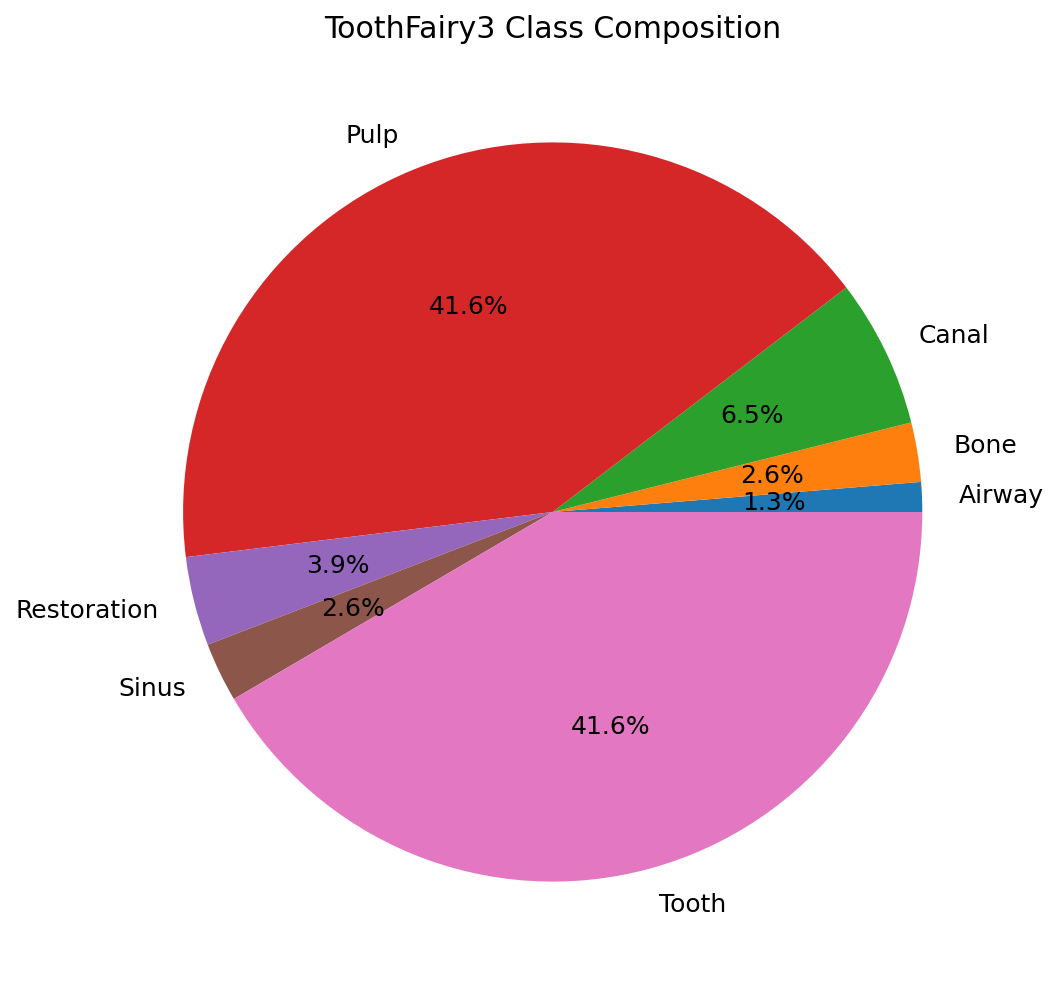

In [11]:
plt.figure(figsize=(8,8))

plt.pie(
    category_table["Count"],
    labels=category_table["Category"],
    autopct="%1.1f%%"
)

plt.title(
    "ToothFairy3 Class Composition"
)

plt.savefig(
    "Figure3_Category_Distribution.png",
    bbox_inches="tight"
)

plt.show()

# Left vs Right Canal Analysis

In [12]:
canals = df[
    df["Label Name"].str.contains(
        "Canal",
        case=False,
        na=False
    )
]

canals[
    [
        "Label Name",
        "Presence %",
        "Mean Voxels"
    ]
]

,Label Name,Presence %,Mean Voxels
1,Left Inferior Alveolar Canal,100.00,14912
2,Right Inferior Alveolar Canal,100.00,15128
4,Lingual Canal,97.56,298
5,Left Mandibular Incisive Canal,94.55,704
6,Right Mandibular Incisive Canal,92.86,644


# Canal Volume Plot

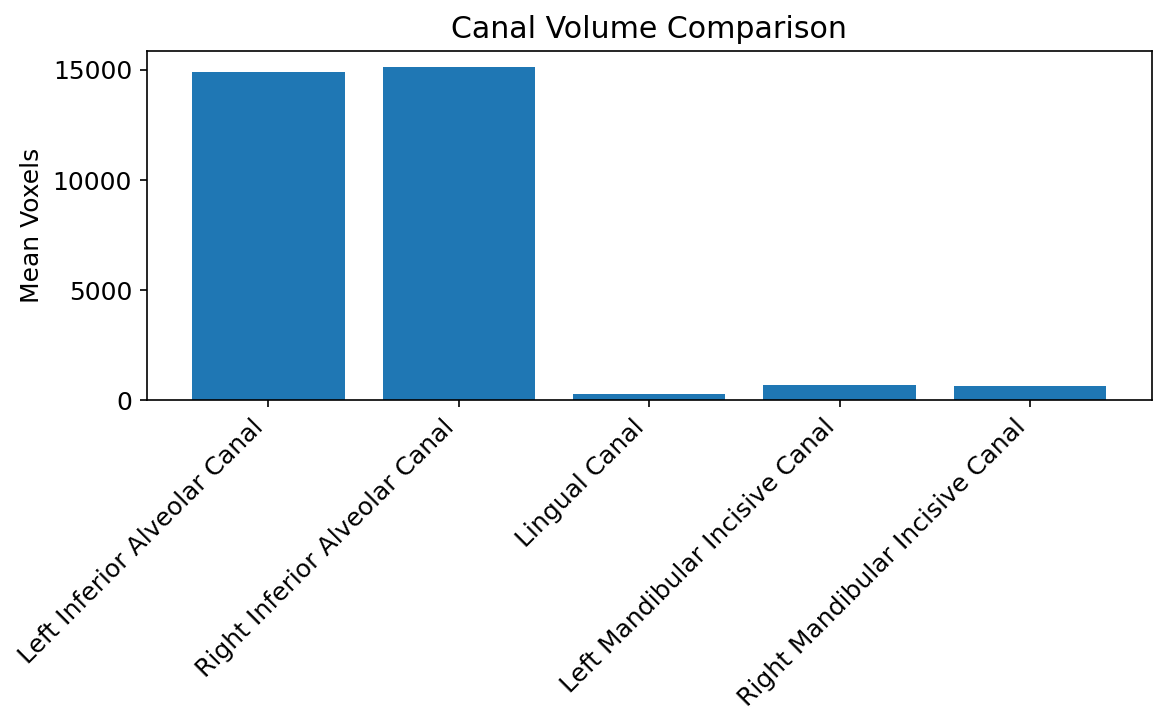

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    canals["Label Name"],
    canals["Mean Voxels"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Mean Voxels")

plt.title(
    "Canal Volume Comparison"
)

plt.tight_layout()

plt.savefig(
    "Figure4_Canal_Comparison.png",
    bbox_inches="tight"
)

plt.show()

# Restoration Statistics

In [14]:
restorations = df[
    df["Category"]=="Restoration"
]

restorations[
    [
        "Label Name",
        "Cases Present",
        "Presence %"
    ]
]

,Label Name,Cases Present,Presence %
59,Crown,193,36.28
73,Bridge,101,18.98
74,Implant,74,13.91


# Generate Final Publication Tables

In [15]:
with pd.ExcelWriter(
    "ToothFairy3_Publication_Report.xlsx"
) as writer:

    df.to_excel(
        writer,
        sheet_name="All Labels",
        index=False
    )

    top20.to_excel(
        writer,
        sheet_name="Top Structures",
        index=False
    )

    category_table.to_excel(
        writer,
        sheet_name="Category Summary",
        index=False
    )

print(
    "Publication report generated"
)

Publication report generated
